# Credit Card Fraud Detection

Binary classification model to flag fraudulent credit card transactions using the [ULB Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (Kaggle / Machine Learning Group, Universite Libre de Bruxelles).

**Dataset**: 284,807 transactions made by European cardholders over two days in September 2013. 492 are fraudulent (0.172%) — a severely imbalanced classification problem. Features `V1`-`V28` are PCA-transformed for confidentiality; only `Time`, `Amount`, and `Class` (target) are in their original form.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    precision_score, recall_score, f1_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [32]:
#pip install imbalanced-learn

## 1. Load & inspect data

In [ ]:

# Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
fd = pd.read_csv('creditcard.csv')
fd.head()



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
fd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
fd.isnull().sum()  # confirm no missing values

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [13]:
fd['Class'].value_counts(), fd['Class'].value_counts(normalize=True) * 100

(Class
 0    284315
 1       492
 Name: count, dtype: int64,
 Class
 0    99.827251
 1     0.172749
 Name: proportion, dtype: float64)

**Severe class imbalance**: 284,315 legitimate transactions (99.83%) vs. 492 fraudulent (0.17%). This ratio drives most of the modeling decisions below - accuracy alone is meaningless here (predicting "not fraud" for everything scores 99.83% accuracy), and standard cross-validation, evaluation metrics, and resampling choices all need to account for it.

## 2. Amount & Time by class

In [14]:
fd.groupby('Class')['Amount'].agg(['mean', 'median', 'sum', 'count'])

,mean,median,sum,count
Class,,,,
0,88.291022,22.00,25102462.04,284315
1,122.211321,9.25,60127.97,492


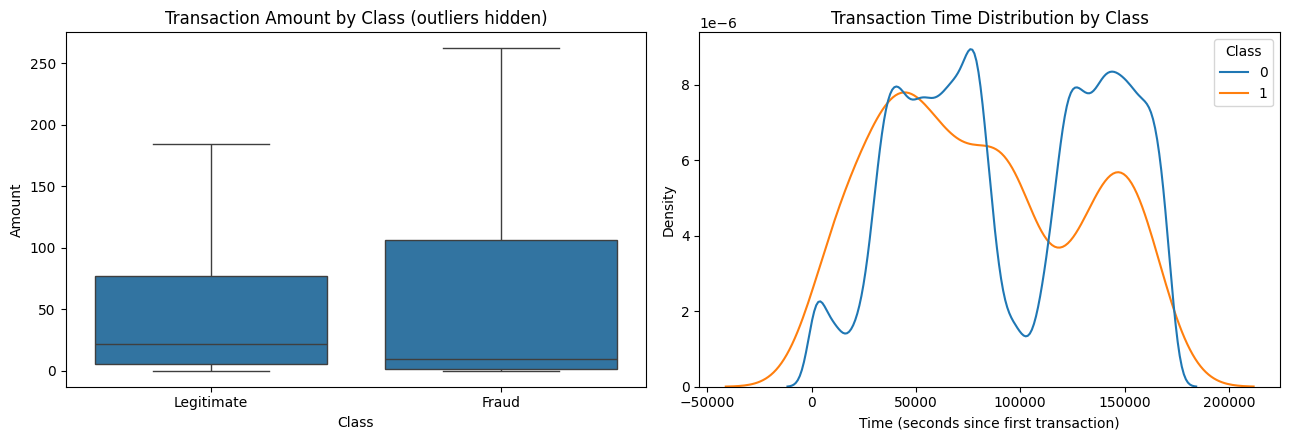

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=fd, x='Class', y='Amount', ax=axes[0], showfliers=False)
axes[0].set_title('Transaction Amount by Class (outliers hidden)')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

sns.kdeplot(data=fd, x='Time', hue='Class', common_norm=False, ax=axes[1])
axes[1].set_title('Transaction Time Distribution by Class')
axes[1].set_xlabel('Time (seconds since first transaction)')

plt.tight_layout()
plt.show()

Fraudulent transactions have a higher *mean* amount (\$122.21 vs \$88.29) but a much lower *median* (\$9.25 vs \$22.00) - the mean is pulled up by a handful of large-value fraud cases, while typical fraudulent charges actually skew toward small amounts (consistent with card testing behavior, where small transactions are used to validate a stolen card before a larger charge). The time-density plot shows fraud is somewhat more evenly spread across the full 48-hour window, without the pronounced day/night dip legitimate transaction volume shows - consistent with automated/non-human-paced fraudulent activity.

## 3. Train / test split

In [16]:
x = fd.drop('Class', axis=1)
y = fd['Class']
x.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount']

In [ ]:
# stratify=y preserves the 99.83/0.17 class ratio in both splits -- essential
# with this few positive cases, a non-stratified split risks skewing the test set
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print(x_train.shape, x_test.shape)
print('Train fraud rate:', y_train.mean())
print('Test fraud rate:', y_test.mean())

(227845, 30) (56962, 30)
Train fraud rate: 0.001729245759178389
Test fraud rate: 0.0017204452090867595


In [18]:
# Feature scaling: V1-V28 are already PCA-transformed (roughly standardized),
# but Time and Amount are on very different scales and need to be standardized too.
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 4. Baseline model: Random Forest

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# 5-fold CV, scored on F1 (not accuracy) because of the class imbalance
cv_scores = cross_val_score(rf_model, x_train_scaled, y_train, cv=5, scoring='f1')
print('CV F1 scores:', cv_scores)
print('Average F1:', cv_scores.mean())

CV F1 scores: [0.80882353 0.86486486 0.82993197 0.84285714 0.85106383]
Average F1: 0.8395082679420245


In [20]:
rf_model.fit(x_train_scaled, y_train)
y_pred = rf_model.predict(x_test_scaled)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9412    0.8163    0.8743        98

    accuracy                         0.9996     56962
   macro avg     0.9704    0.9081    0.9371     56962
weighted avg     0.9996    0.9996    0.9996     56962



At the default 0.5 threshold: precision 0.94, recall 0.82, F1 0.87 on the fraud class. In plain terms - of the 98 fraudulent transactions in the test set, the model correctly flags 80 and misses 18, while incorrectly flagging only 5 legitimate transactions. That's a real, defensible result for a rare-event problem like this (unlike a suspiciously perfect score, which would be a red flag rather than a win).

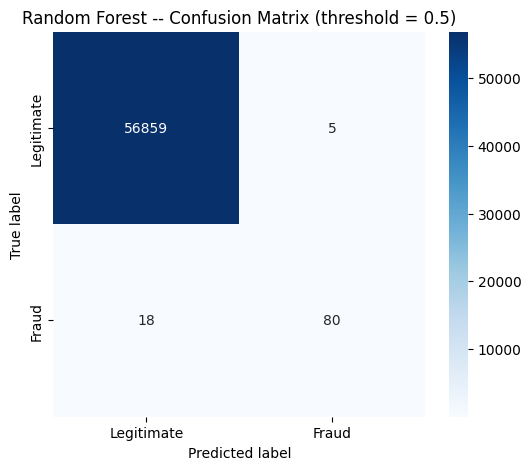

array([[56859,     5],
       [   18,    80]])

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Random Forest -- Confusion Matrix (threshold = 0.5)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()
cm

## 5. Feature importance

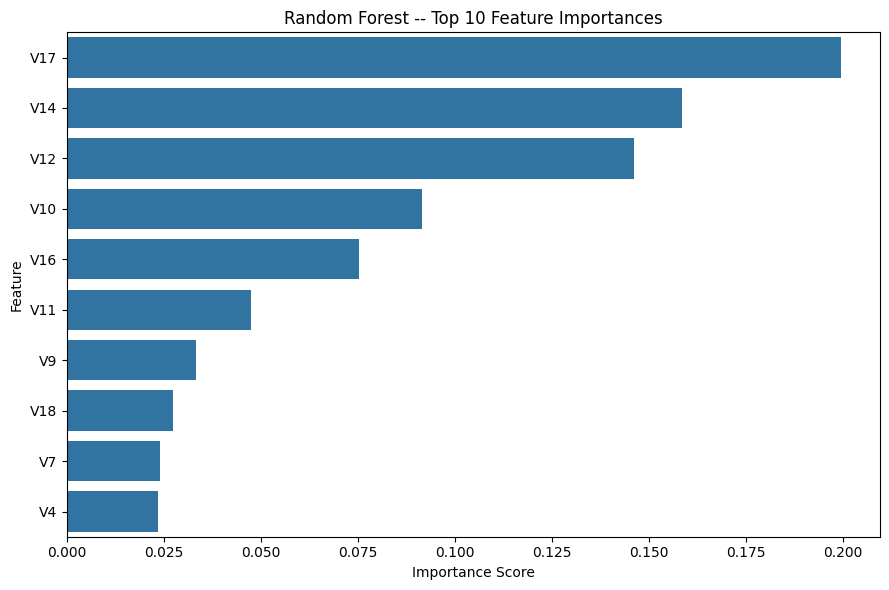

,Feature,Importance
17,V17,0.199628
14,V14,0.158528
12,V12,0.146251
10,V10,0.091723
16,V16,0.075448
11,V11,0.047485
9,V9,0.033294
18,V18,0.027467
7,V7,0.024119
4,V4,0.023464


In [22]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature')
plt.title('Random Forest -- Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
importance.head(10)

`V17`, `V14`, and `V12` are the three strongest predictors by a clear margin. Because `V1`-`V28` are anonymized PCA components, we can't attach a literal business meaning to them (e.g. "V17 = spending category"), but their relative ranking is still useful: it tells us the fraud signal is concentrated in a small number of components rather than spread evenly, which is consistent with fraud being driven by a few underlying behavioral patterns picked up by the original (pre-PCA) transaction features.

## 6. Feature correlation

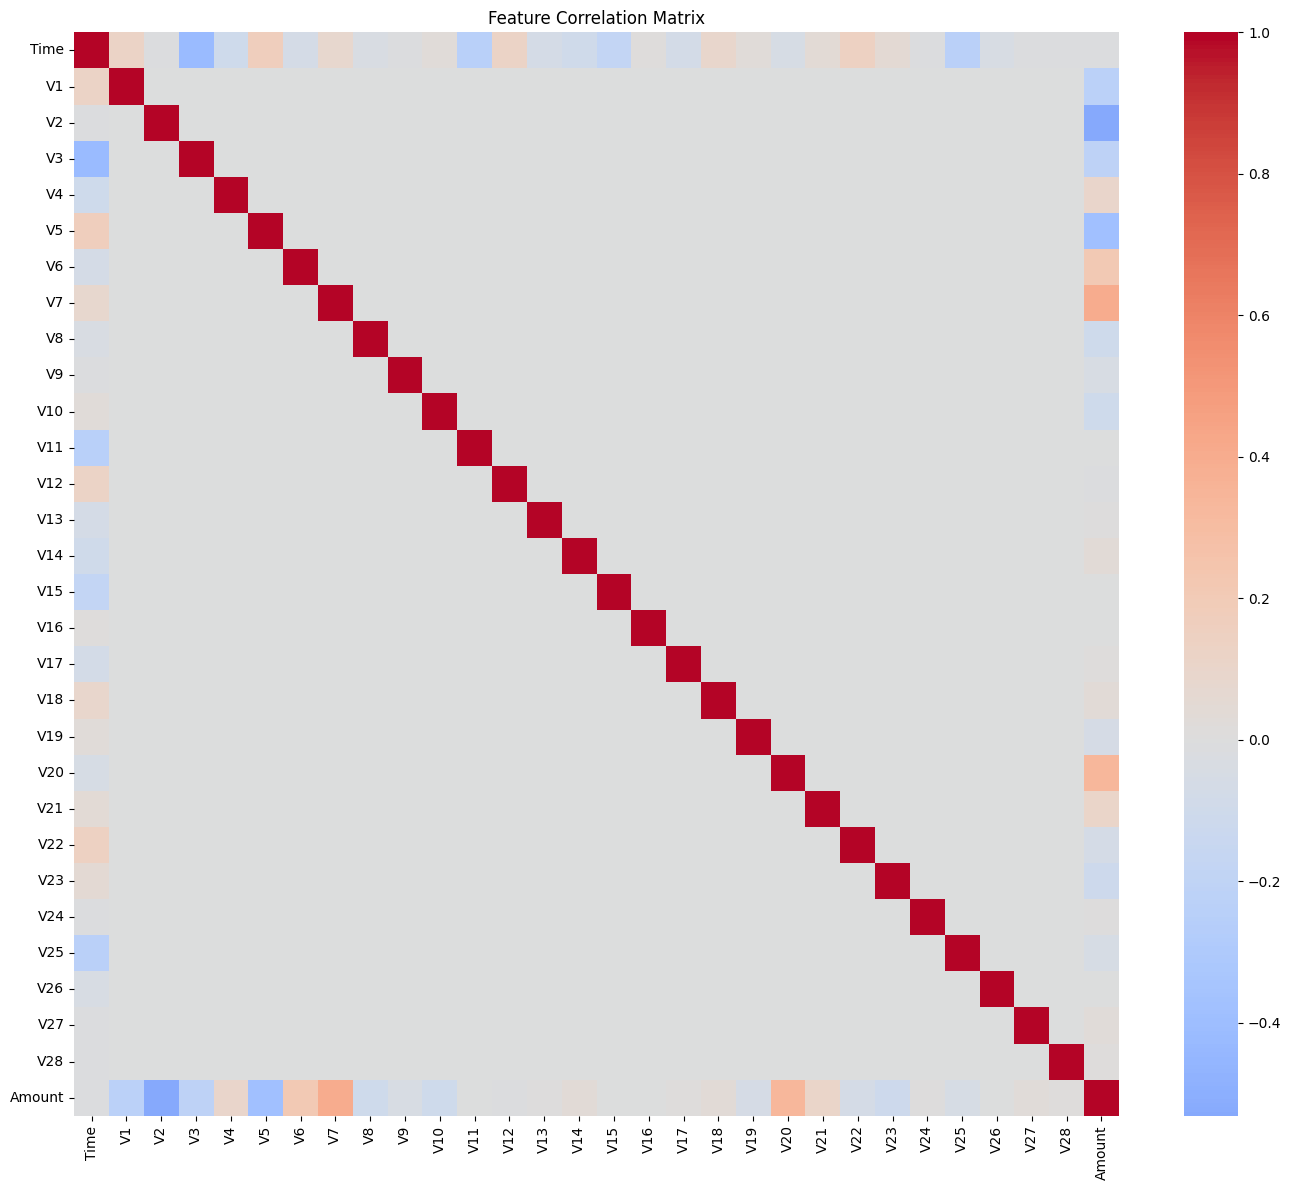

In [23]:
plt.figure(figsize=(14, 12))
corr = x.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [24]:
from itertools import combinations

corr_pairs = pd.DataFrame(
    [(a, b, corr.loc[a, b]) for a, b in combinations(x.columns, 2)],
    columns=['Feature 1', 'Feature 2', 'Correlation']
)
corr_pairs = corr_pairs.reindex(corr_pairs['Correlation'].abs().sort_values(ascending=False).index)
corr_pairs.head(8)

,Feature 1,Feature 2,Correlation
83,V2,Amount,-0.531409
2,Time,V3,-0.419618
203,V7,Amount,0.397311
158,V5,Amount,-0.386356
398,V20,Amount,0.339403
10,Time,V11,-0.247689
24,Time,V25,-0.233083
56,V1,Amount,-0.227709


The `V1`-`V28` components are PCA-derived, so by construction they're nearly uncorrelated with each other - and the heatmap confirms that (no V-to-V pair exceeds ~|0.25|). The strongest real relationships involve `Amount` and `Time`, the two features that weren't part of the PCA transform: `V2` vs. `Amount` (-0.53) and `V3` vs. `Time` (-0.42) are the largest. There's no multicollinearity concern here worth acting on.

## 7. ROC and Precision-Recall curves

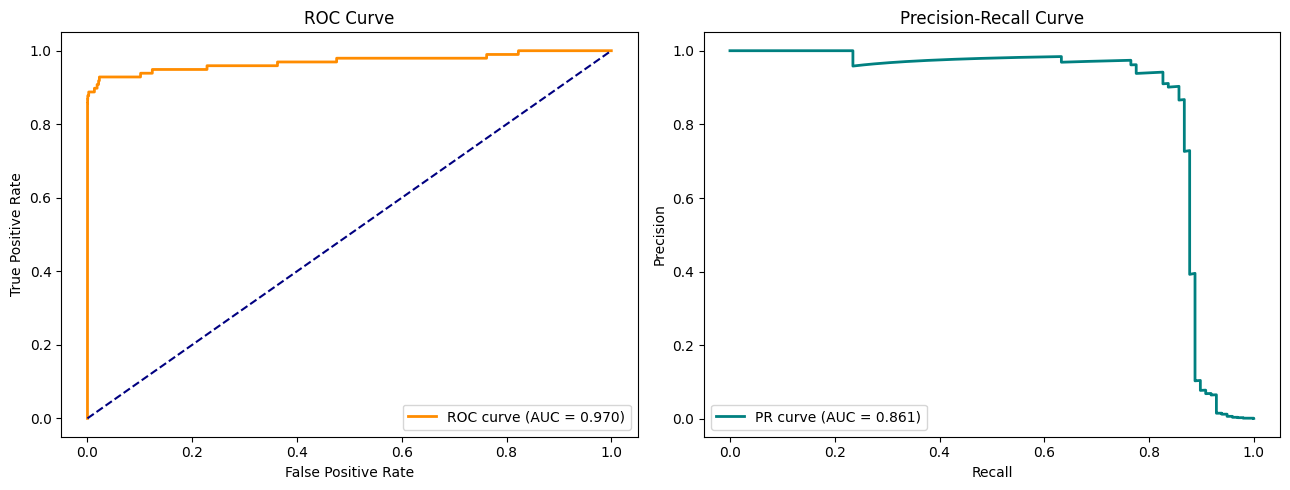

ROC-AUC: 0.9698278491897603
PR-AUC: 0.8611749795632782


In [25]:
y_proba = rf_model.predict_proba(x_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recalls, precisions)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

axes[1].plot(recalls, precisions, color='teal', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

print('ROC-AUC:', roc_auc)
print('PR-AUC:', pr_auc)

ROC-AUC (0.970) looks strong, but with only 0.17% positives it's known to be an optimistic metric for imbalanced problems - it's dominated by the (huge, easy) true-negative rate. The precision-recall curve (PR-AUC 0.861) is the more honest picture here, since it only scores performance on the class we actually care about. Both are shown, but PR is what we'll use to compare models below.

## 8. Does resampling help? Testing SMOTE and class weighting

The standard playbook for imbalanced classification is to rebalance the training data - either by oversampling the minority class (SMOTE) or reweighting the loss function (`class_weight='balanced'`). Both are tested below **and compared against the untouched baseline on PR-AUC**, rather than assumed to help by default.

In [26]:
# SMOTE applied to the *training* set only, scaled features, moderate 0.5 ratio
# (i.e. synthetic fraud examples brought up to 50% of the majority class, not full 1:1 --
# full balancing would nearly double the training set for a fairly small expected gain)
smote = SMOTE(sampling_strategy=0.5, random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train_scaled, y_train)
print('Before SMOTE:', np.bincount(y_train))
print('After SMOTE: ', np.bincount(y_train_sm))

rf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf_smote.fit(x_train_sm, y_train_sm)

y_proba_sm = rf_smote.predict_proba(x_test_scaled)[:, 1]
p_sm, r_sm, _ = precision_recall_curve(y_test, y_proba_sm)
pr_auc_sm = auc(r_sm, p_sm)
print('SMOTE(0.5) PR-AUC:', pr_auc_sm)

Before SMOTE: [227451    394]
After SMOTE:  [227451 113725]
SMOTE(0.5) PR-AUC: 0.8387503608299155


In [27]:
rf_cw = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=5,
    random_state=42, class_weight='balanced'
)
rf_cw.fit(x_train_scaled, y_train)

y_proba_cw = rf_cw.predict_proba(x_test_scaled)[:, 1]
p_cw, r_cw, _ = precision_recall_curve(y_test, y_proba_cw)
pr_auc_cw = auc(r_cw, p_cw)
print('class_weight=balanced PR-AUC:', pr_auc_cw)

class_weight=balanced PR-AUC: 0.8352839680110421


In [28]:
comparison = pd.DataFrame({
    'Approach': ['Baseline (no resampling)', 'SMOTE (0.5 ratio)', "class_weight='balanced'"],
    'PR-AUC': [pr_auc, pr_auc_sm, pr_auc_cw]
}).sort_values('PR-AUC', ascending=False)
comparison

,Approach,PR-AUC
0,Baseline (no resampling),0.861175
1,SMOTE (0.5 ratio),0.838750
2,class_weight='balanced',0.835284


**Neither SMOTE nor class-weighting improves on the untouched baseline** - both score lower on PR-AUC. This is a useful negative result, not a dead end: Random Forest's own bagging already handles moderate imbalance reasonably well, and both rebalancing techniques here shifted the decision boundary in a way that added false positives without a proportional recall gain (checked directly via a threshold sweep on each model; the baseline's best achievable F1 at any threshold, ~0.87, beats SMOTE's best of ~0.79 and class-weighting's best of ~0.83). **The baseline model, without resampling, is kept as the final model** - and threshold tuning (next section) is used instead as the lever for adjusting the precision/recall trade-off.

## 9. Threshold tuning

In [29]:
avg_fraud_amt = fd.loc[fd['Class'] == 1, 'Amount'].mean()

thresholds_to_test = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
rows = []
for t in thresholds_to_test:
    pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    fn, fp, tp = int(cm_t[1][0]), int(cm_t[0][1]), int(cm_t[1][1])
    rows.append({
        'Threshold': t,
        'Precision': round(precision_score(y_test, pred_t, zero_division=0), 4),
        'Recall': round(recall_score(y_test, pred_t, zero_division=0), 4),
        'F1': round(f1_score(y_test, pred_t, zero_division=0), 4),
        'False Negatives': fn,
        'False Positives': fp,
        'Est. $ Missed': round(fn * avg_fraud_amt, 2),
        'Reviews Triggered (TP+FP)': tp + fp,
    })
threshold_df = pd.DataFrame(rows)
threshold_df

,Threshold,Precision,Recall,F1,False Negatives,False Positives,Est. $ Missed,Reviews Triggered (TP+FP)
0,0.9,0.9792,0.4796,0.6438,51,1,6232.78,48
1,0.8,0.9839,0.6224,0.7625,37,1,4521.82,62
2,0.7,0.9710,0.6837,0.8024,31,2,3788.55,69
3,0.6,0.9620,0.7755,0.8588,22,3,2688.65,79
4,0.5,0.9412,0.8163,0.8743,18,5,2199.80,85
5,0.4,0.9111,0.8367,0.8723,16,8,1955.38,90
6,0.3,0.8673,0.8673,0.8673,13,13,1588.75,98
7,0.2,0.8019,0.8673,0.8333,13,21,1588.75,106
8,0.1,0.7107,0.8776,0.7854,12,35,1466.54,121


The default 0.5 threshold maximizes F1 (0.874), but F1 implicitly treats a missed fraud and a false alarm as equally costly - which isn't true here. The average fraudulent transaction is **\$122.21**; a false positive just means one legitimate transaction gets held for a manual check or a customer confirmation, a far cheaper outcome than letting a $122 fraud through. Given that asymmetry, **threshold 0.3** is the better operating point: it catches 85 of 98 frauds (13 missed, down from 18) at the cost of 13 false positives (up from 5) - a reasonable trade given the cost gap between the two error types.

Final model: baseline Random Forest, threshold = 0.3

              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998     56864
           1     0.8673    0.8673    0.8673        98

    accuracy                         0.9995     56962
   macro avg     0.9336    0.9336    0.9336     56962
weighted avg     0.9995    0.9995    0.9995     56962



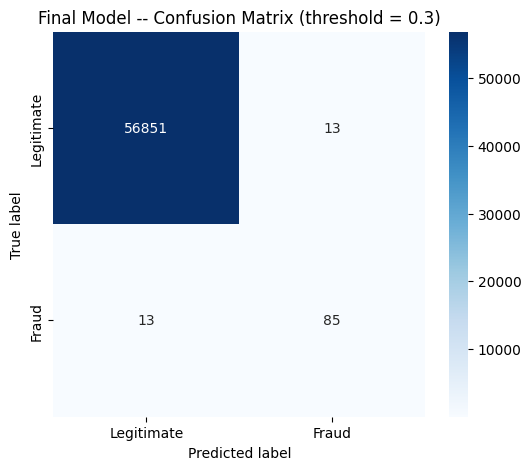

In [30]:
FINAL_THRESHOLD = 0.3
y_pred_final = (y_proba >= FINAL_THRESHOLD).astype(int)

print(f'Final model: baseline Random Forest, threshold = {FINAL_THRESHOLD}\n')
print(classification_report(y_test, y_pred_final, digits=4))

cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Final Model -- Confusion Matrix (threshold = {FINAL_THRESHOLD})')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## 10. Business summary

In [31]:
n_fraud_test = int(y_test.sum())
tp = int(cm_final[1][1]); fn = int(cm_final[1][0]); fp = int(cm_final[0][1])
avg_fraud_amt = fd.loc[fd['Class'] == 1, 'Amount'].mean()

print(f'Of {n_fraud_test} fraudulent transactions in the test set:')
print(f'  - {tp} caught (~${tp*avg_fraud_amt:,.2f} in prevented losses at the average fraud amount)')
print(f'  - {fn} missed (~${fn*avg_fraud_amt:,.2f} in exposure at the average fraud amount)')
print(f'  - {fp} legitimate transactions flagged for review (false positives)')

Of 98 fraudulent transactions in the test set:
  - 85 caught (~$10,387.96 in prevented losses at the average fraud amount)
  - 13 missed (~$1,588.75 in exposure at the average fraud amount)
  - 13 legitimate transactions flagged for review (false positives)


**Final model**: Random Forest (100 trees, max depth 10), no resampling, decision threshold set to 0.3 instead of the default 0.5.

**Why**: SMOTE and class-weighting were both tested and empirically underperformed the untouched baseline on PR-AUC, so neither was adopted. Threshold tuning was used instead to shift the precision/recall trade-off toward recall, justified by the asymmetric cost of missing a ~\$122 average fraud versus the low cost of one extra manual review.

**Caveats for anyone using this model**:
- `V1`-`V28` are PCA components with no literal business meaning, so the drivers behind `V17`/`V14`/`V12` can't be explained to a fraud analyst in plain language - only that they matter.
- This is a two-day snapshot from a single (undisclosed) European issuer in 2013; fraud patterns drift over time and by region, so periodic retraining would be necessary in production, not a one-time fit.
- The 0.3 threshold assumes a manual-review cost well below \$122; if the actual investigation cost per flagged transaction is known, this threshold should be re-derived from that number rather than the general assumption used here.